<a href="https://colab.research.google.com/github/stacykeago/predictive-data-analytics/blob/main/set%20exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

## Import the libraries

In [1]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Upload the datasets

In [2]:
url = 'https://drive.google.com/uc?export=download&id=1o2zNGpyc7llWJCPbf6RXCJuweYCfrvnt'
data = pd.read_csv(url)
data.head(10)

,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.80730,-0.44699,0.0
1,4.54590,8.1674,-2.45860,-1.46210,0.0
2,3.86600,-2.6383,1.92420,0.10645,0.0
3,3.45660,9.5228,-4.01120,-3.59440,0.0
4,0.32924,-4.4552,4.57180,-0.98880,0.0
5,4.36840,9.6718,-3.96060,-3.16250,0.0
6,3.59120,3.0129,0.72888,0.56421,0.0
7,2.09220,-6.8100,8.46360,-0.60216,0.0
8,3.20320,5.7588,-0.75345,-0.61251,0.0
9,1.53560,9.1772,-2.27180,-0.73535,0.0


## Check for the rows and columns

In [3]:
# Print number of rows and columns
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Rows: 1375, Columns: 5


## Check the data types

In [4]:
data.dtypes

,0
X1,float64
X2,float64
X3,float64
X4,float64
Label,float64


## check for missing values

### check for symbols in the data

In [5]:
for col in data.columns:
    count = data[col].astype(str).str.contains(r'[^a-zA-Z0-9\s.]', na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")

Column 'X1' has 609 rows with symbols.
Column 'X2' has 465 rows with symbols.
Column 'X3' has 586 rows with symbols.
Column 'X4' has 902 rows with symbols.


## check for anomalies

In [9]:
from sklearn.ensemble import IsolationForest

# Select numerical features for anomaly detection
features = ['X1', 'X2', 'X3', 'X4']

# Train Isolation Forest
# contamination=0.05 means we expect roughly 5% of the data to be anomalous
iso = IsolationForest(contamination=0.05, random_state=42)
data['anomaly_score'] = iso.fit_predict(data[features])

# Isolation Forest outputs -1 for anomalies and 1 for normal data
anomalies = data[data['anomaly_score'] == -1]
clean_data = data[data['anomaly_score'] == 1]

print(f"Detected {len(anomalies)} anomalies out of {len(data)} rows.")

Detected 69 anomalies out of 1375 rows.


## check for outliers

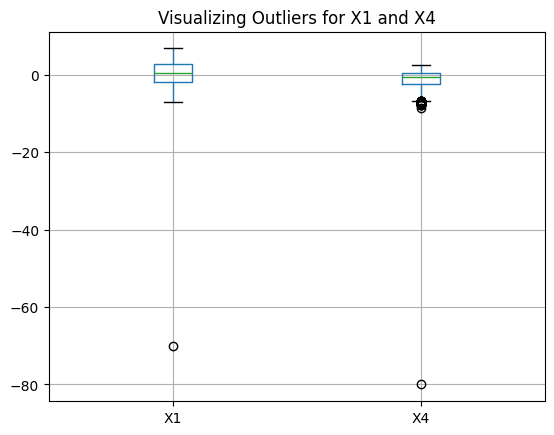

In [7]:
import matplotlib.pyplot as plt

# Boxplot for X1 and X4 to visually inspect outliers
data[['X1', 'X4']].boxplot()
plt.title("Visualizing Outliers for X1 and X4")
plt.show()

## Unique features

In [11]:
data.nunique()

,0
X1,1339
X2,1257
X3,1271
X4,1157
Label,2
anomaly_score,2


## Check for duplicates

In [12]:
#check for duplicates : Duplicates are noise to the data
np.sum(data.duplicated())

np.int64(25)

# Statistical analysis of the data

In [6]:
data.describe()

,X1,X2,X3,X4,Label
count,1375.000000,1375.000000,1375.000000,1375.000000,1374.000000
mean,0.386657,2.014202,1.359162,-1.250522,0.443959
std,3.418977,6.676094,4.527056,2.987968,0.497030
min,-70.000000,-13.773100,-50.000000,-80.000000,0.000000
25%,-1.774700,-1.697850,-1.630450,-2.428000,0.000000
50%,0.496650,2.325900,0.616630,-0.586650,0.000000
75%,2.822050,6.819300,3.181600,0.394810,1.000000
max,6.824800,120.000000,17.927400,2.449500,1.000000


## Check for skewness

In [13]:


# Check skewness (0 is perfectly symmetrical, positive/negative shows asymmetry)
print("\nSkewness of features:")
print(data[['X1', 'X2', 'X3', 'X4']].skew())


Skewness of features:
X1    -6.414611
X2     3.725900
X3    -0.104679
X4   -13.669247
dtype: float64


In [14]:
# Count and percentage of each class
print(data['Label'].value_counts())
print(data['Label'].value_counts(normalize=True) * 100)

Label
0.0    764
1.0    610
Name: count, dtype: int64
Label
0.0    55.604076
1.0    44.395924
Name: proportion, dtype: float64


# Univariate analysis

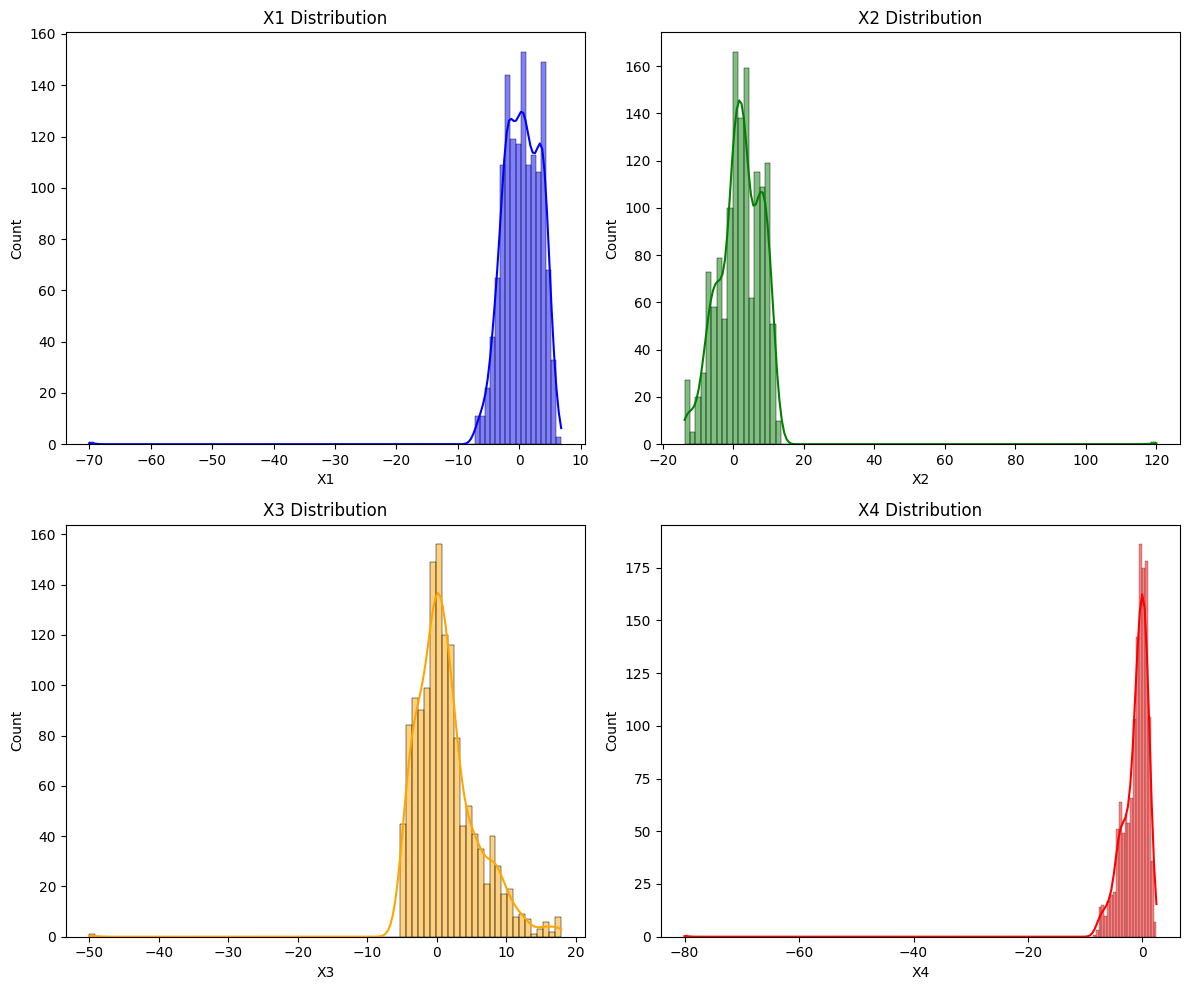

In [15]:
# Set up the plotting grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot distributions
sns.histplot(data['X1'], kde=True, ax=axes[0, 0], color='blue').set_title('X1 Distribution')
sns.histplot(data['X2'], kde=True, ax=axes[0, 1], color='green').set_title('X2 Distribution')
sns.histplot(data['X3'], kde=True, ax=axes[1, 0], color='orange').set_title('X3 Distribution')
sns.histplot(data['X4'], kde=True, ax=axes[1, 1], color='red').set_title('X4 Distribution')

plt.tight_layout()
plt.show()

# Bivariate Analysis

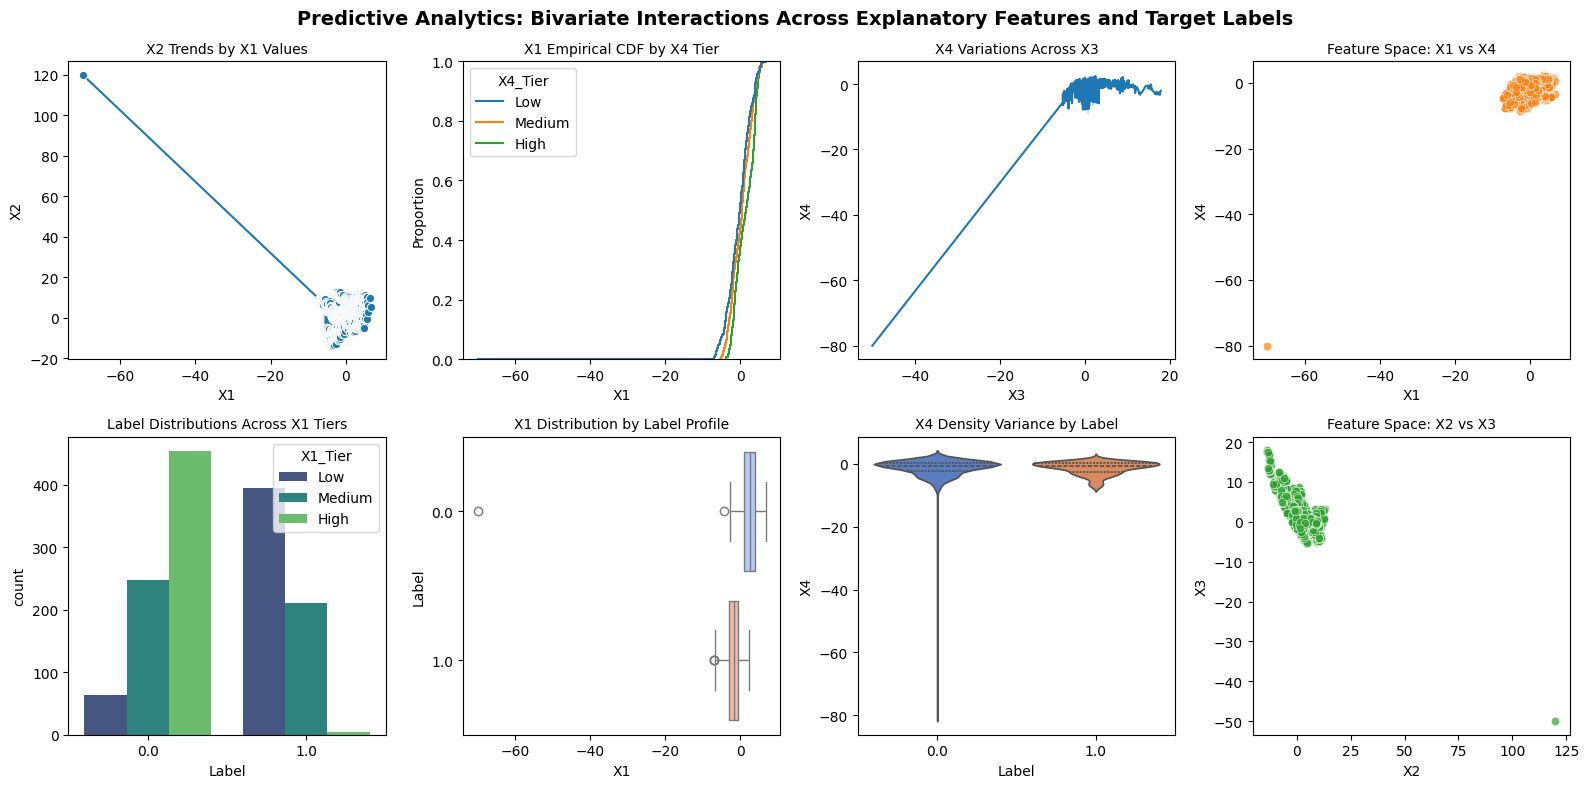

In [17]:

# 1. Create the working dataframe using your variable 'data'
df = data.copy()

# Segment X1 and X4 into high/medium/low tiers for distributional analysis
df["X1_Tier"] = pd.qcut(df["X1"], q=3, labels=["Low", "Medium", "High"])
df["X4_Tier"] = pd.qcut(df["X4"], q=3, labels=["Low", "Medium", "High"])

# 2. Layout Config (2x4 grid to match your exact configuration)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plt.suptitle(
    "Predictive Analytics: Bivariate Interactions Across Explanatory Features and Target Labels",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

# Configuration mapping your exact visual elements to the current dataset
cfg = [
    (sns.lineplot, {"data": df, "x": "X1", "y": "X2", "marker": "o", "errorbar": None}, "X2 Trends by X1 Values"),
    (sns.ecdfplot, {"data": df, "x": "X1", "hue": "X4_Tier"}, "X1 Empirical CDF by X4 Tier"),
    (sns.lineplot, {"data": df, "x": "X3", "y": "X4", "errorbar": "sd"}, "X4 Variations Across X3"),
    (sns.scatterplot, {"data": df, "x": "X1", "y": "X4", "alpha": 0.7, "color": "#ff7f0e"}, "Feature Space: X1 vs X4"),
    (sns.countplot, {"data": df, "x": "Label", "hue": "X1_Tier", "palette": "viridis"}, "Label Distributions Across X1 Tiers"),
    (sns.boxplot, {"data": df, "x": "X1", "y": "Label", "hue": "Label", "orient": "h", "legend": False, "palette": "coolwarm"}, "X1 Distribution by Label Profile"),
    (sns.violinplot, {"data": df, "x": "Label", "y": "X4", "hue": "Label", "legend": False, "palette": "muted", "inner": "quart"}, "X4 Density Variance by Label"),
    (sns.scatterplot, {"data": df, "x": "X2", "y": "X3", "alpha": 0.7, "color": "#2ca02c"}, "Feature Space: X2 vs X3"),
]

# Execute the plot rendering loop
for idx, (func, kwargs, title) in enumerate(cfg):
    func(ax=axes[idx], **kwargs)
    axes[idx].set_title(title, fontsize=10)
    # Adjust axes formatting for readability
    if "Label" in str(kwargs.get("x")) or "Label" in str(kwargs.get("y")):
        axes[idx].tick_params(axis="x", labelrotation=0)

plt.tight_layout()
plt.show()

# Multivariate analsis



--- Correlation Matrix Values ---
             X1        X2        X3        X4     Label
X1     1.000000 -0.071052 -0.131838  0.555721 -0.589207
X2    -0.071052  1.000000 -0.804550 -0.664870 -0.402669
X3    -0.131838 -0.804550  1.000000  0.431833  0.156423
X4     0.555721 -0.664870  0.431833  1.000000  0.001343
Label -0.589207 -0.402669  0.156423  0.001343  1.000000


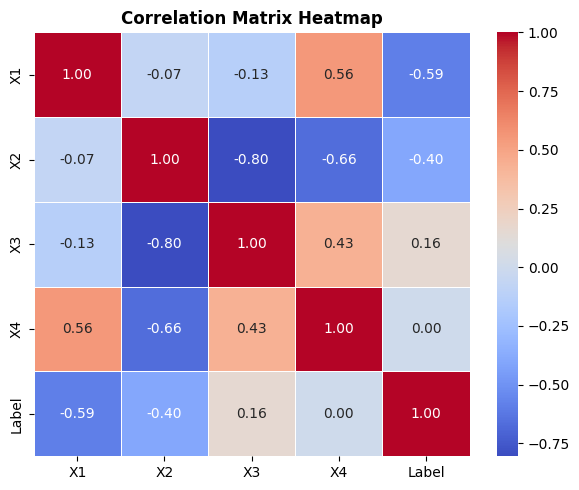

In [18]:
# Compute the correlation matrix for features and label
corr_matrix = df[['X1', 'X2', 'X3', 'X4', 'Label']].corr()

# Display the numerical values
print("--- Correlation Matrix Values ---")
print(corr_matrix)

# Plot the matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Probability of classes ‘0’ and ‘1’

In [19]:
# Count occurrences of each class
class_counts = df['Label'].value_counts()

# Calculate total instances
total_instances = len(df)

# Determine the probabilities
prob_0 = class_counts.get(0, 0) / total_instances
prob_1 = class_counts.get(1, 0) / total_instances

print(f"Total instances: {total_instances}")
print(f"Number of 0s: {class_counts.get(0, 0)} | Probability (P_0): {prob_0:.4f}")
print(f"Number of 1s: {class_counts.get(1, 0)} | Probability (P_1): {prob_1:.4f}")

Total instances: 1375
Number of 0s: 764 | Probability (P_0): 0.5556
Number of 1s: 610 | Probability (P_1): 0.4436
